[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/imbishal7/CSC-428/blob/main/notebooks/CSC428_project.ipynb)

# CSC428 Final Project — ML Side-Channel Attack on AES (ASCAD)

**Suwan Aryal** · **Kapil Sharma**

> Single-trace classification: from one 700-sample power trace recorded during a masked-AES execution, predict the Hamming weight (0–8) of the masked S-box output.

## Background and motivation

**AES (Advanced Encryption Standard)** is the symmetric-key cipher that protects almost every encrypted byte you see — TLS, disk encryption, WPA3, file vaults. Mathematically the cipher is unbroken: with current public knowledge there is no shortcut to recovering an AES-128 key short of trying all 2¹²⁸ possibilities.

**Side-channel attacks** sidestep the math entirely. While the chip is computing AES, it consumes power, emits electromagnetic radiation, takes time, and dissipates heat. Each of those physical channels leaks information that *correlates* with the secret bits being processed. A **power-analysis side-channel attack** records the chip's instantaneous power consumption with an oscilloscope and uses that signal to recover the key — no math needed, just a probe and a trained model.

**Boolean masking** is a software countermeasure designed to break this leakage. Instead of computing `Sbox(p ⊕ k)` directly, the chip computes `Sbox(p ⊕ k) ⊕ m`, where `m` is a fresh random byte per execution. The masked value is what gets latched into a register and what the trace physically leaks; the unmasked value is never on any wire at first order. To recover the key, the attacker must either (a) profile a clone device whose masks they can read, or (b) combine multiple time samples within a trace where the mask leaks separately — *higher-order analysis*.

**This project** trains three machine-learning models — logistic regression, MLP, and CNN — to perform the (a) version: *known-mask single-trace classification* on ASCAD. We use stratified 5-fold cross-validation to quantify accuracy with statistical confidence and compare what the three model families can learn from the same data.

## About the ASCAD dataset

**ASCAD** (ANSSI SCA Database) is the field's MNIST: a public benchmark for evaluating side-channel attacks on a real device. ANSSI (the French national cybersecurity agency) released it in 2018 specifically so that ML methods could be compared on a level playing field.

| Property | Value |
|---|---|
| Target device | ATMega8515 (8-bit AVR microcontroller) |
| Implementation | Software AES-128 with first-order boolean masking |
| Measurement | EM/power probe, digital oscilloscope |
| Variant we use | Fixed-key, synchronized (`ASCAD.h5`) |
| Profiling traces | 50,000 |
| Attack traces | 10,000 |
| Samples per trace | 700 |
| Trace dtype | `int8` (oscilloscope quantized) |
| Target | Hamming weight of `Sbox(plaintext[2] ⊕ key[2]) ⊕ mask_out` ∈ {0, …, 8} |

Each trace is the chip's power needle moving over time during *one* AES encryption. The 700-sample window is hand-picked by ANSSI to surround the round-1 S-box computation for byte index 2 — that's the moment when the secret key byte first interacts with public plaintext, so it's the leakiest spot in the entire encryption.

ASCAD ships extra metadata per trace — the plaintext, key, and the masks the chip used at runtime. The masks are essential: they're what lets us reconstruct the value the trace physically leaks (more on this in section 2).

## Pipeline

1. **Data downloading and loading** — pull `ASCAD.h5` and build one DataFrame: 700 trace columns + 1 label column, 60,000 rows.
2. **Data cleaning + label engineering** — verify integrity, then auto-detect which mask byte to XOR with the unmasked label so the trace becomes learnable. Standardize features.
3. **Train/test split** — stratified 5-fold cross-validation over the full 60,000 rows.
4. **Models** — Logistic Regression, MLP, CNN; same fold splits and same training protocol for all three.
5. **Results** — mean ± std test accuracy across folds, per-fold variability plots, confusion matrix on a representative model.

## Section 0 — Colab setup
Mount Drive, clone the repo (first run only), install dependencies.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive
![ -d CSC-428 ] || git clone https://github.com/imbishal7/CSC-428.git
%cd CSC-428
!pip install -q -r requirements.txt
!nvidia-smi -L

Mounted at /content/drive
/content/drive/MyDrive
/content/drive/MyDrive/CSC-428
GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-a6f1050c-30a5-029e-2c4b-f033a9a095fc)


In [2]:
# Plot styling for the rest of the notebook
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', palette='deep', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 160,
    'figure.facecolor': 'white',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

## 1. Data downloading and loading

ANSSI publishes ASCAD as a single ~4.2 GB zip. The download script grabs it and extracts `ASCAD.h5` into `data/`, idempotently.

We then read the HDF5 file and build one combined `pandas.DataFrame` containing every available trace — 50,000 profiling + 10,000 attack = **60,000 rows**. Columns:

- `t_0, t_1, …, t_699` — the 700 oscilloscope samples per trace (raw features).
- `label` — integer 0–8 we'll predict (filled in section 2 once we identify the right mask byte).

We hold the unmasked S-box value and the per-trace masks in temporary numpy arrays just long enough to derive `label`; once `label` is computed they aren't part of the DataFrame so it stays clean (features + target only).

In [3]:
!python scripts/download_data.py

already present: data/ASCAD.h5 (0.05 GB)


In [4]:
import h5py
import numpy as np
import pandas as pd

HW_TABLE = np.array([bin(i).count('1') for i in range(256)], dtype=np.int64)

with h5py.File('data/ASCAD.h5', 'r') as f:
    traces = np.concatenate([
        np.array(f['Profiling_traces/traces'], dtype=np.float32),
        np.array(f['Attack_traces/traces'],     dtype=np.float32),
    ], axis=0)
    sbox_unmasked = np.concatenate([
        np.array(f['Profiling_traces/labels'], dtype=np.int64),
        np.array(f['Attack_traces/labels'],     dtype=np.int64),
    ], axis=0)
    masks = np.concatenate([
        np.array(f['Profiling_traces/metadata']['masks'], dtype=np.int64),
        np.array(f['Attack_traces/metadata']['masks'],     dtype=np.int64),
    ], axis=0)

n, n_samples = traces.shape
print(f'combined: {n:,} traces  ×  {n_samples} samples each')
print(f'mask bytes per trace: {masks.shape[1]}')

feature_cols = [f't_{i}' for i in range(n_samples)]
df = pd.DataFrame(traces, columns=feature_cols)
df['label'] = -1   # placeholder; computed in section 2 once the right mask byte is picked

print(f'\ndf shape: {df.shape}')
print('df.head() (first 5 trace columns + label):')
df[feature_cols[:5] + ['label']].head()

combined: 60,000 traces  ×  700 samples each
mask bytes per trace: 16

df shape: (60000, 701)
df.head() (first 5 trace columns + label):


,t_0,t_1,t_2,t_3,t_4,label
0,20.0,19.0,13.0,6.0,-2.0,-1
1,22.0,20.0,15.0,8.0,-1.0,-1
2,24.0,22.0,18.0,12.0,3.0,-1
3,24.0,23.0,18.0,11.0,2.0,-1
4,21.0,20.0,16.0,9.0,1.0,-1


In [5]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 701 entries, t_0 to label
dtypes: float32(700), int64(1)
memory usage: 160.7 MB


In [6]:
# Statistical summary across a representative slice of trace columns (every 100th)
df[feature_cols[::100]].describe().round(2)

,t_0,t_100,t_200,t_300,t_400,t_500,t_600
count,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00
mean,20.00,1.20,10.25,-38.80,-33.82,-5.05,11.33
std,2.76,2.49,4.00,2.94,1.84,2.83,0.86
min,10.00,-9.00,-4.00,-47.00,-39.00,-14.00,8.00
25%,18.00,-1.00,7.00,-41.00,-35.00,-7.00,11.00
50%,20.00,1.00,10.00,-39.00,-34.00,-5.00,11.00
75%,22.00,3.00,13.00,-37.00,-32.00,-3.00,12.00
max,30.00,10.00,23.00,-29.00,-29.00,4.00,14.00


### What does a single power trace look like?

Each row in `df` is the chip's instantaneous power consumption sampled 700 times during one AES encryption. The y-axis is a relative voltage reading (the oscilloscope's int8 output, range −128…+127); the x-axis is sample index in time. The interesting structure is hard to see in a single trace because it's mostly noise, but consistent peaks emerge once we average many traces or compute SNR (next section).

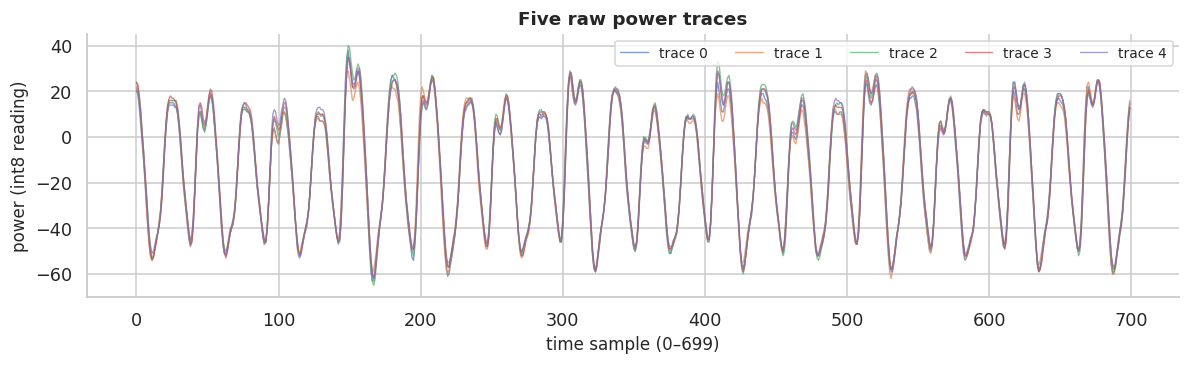

In [7]:
# Five raw example traces overlaid (before standardization)
fig, ax = plt.subplots(figsize=(11, 3.5))
for i in range(5):
    ax.plot(df.iloc[i, :n_samples].values, alpha=0.7, linewidth=0.9, label=f'trace {i}')
ax.set(title='Five raw power traces', xlabel='time sample (0–699)', ylabel='power (int8 reading)')
ax.legend(loc='upper right', ncol=5, fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()

## 2. Data cleaning + label engineering

**(a) Sanity checks.** No NaN/Inf in the trace columns.

**(b) Pick the right label.** This is the critical step. Because of boolean masking, the trace physically leaks `Sbox(p ⊕ k) ⊕ mask_out`, not `Sbox(p ⊕ k)`. We auto-detect which mask byte is the relevant `mask_out` by computing per-sample SNR for every candidate `HW(Sbox(p^k) ⊕ masks[:, m])` and picking the column with the highest peak. The unmasked label has SNR ≈ 0 by design (the mask hides it from any single trace), so the difference is unmistakable.

**(c) Standardize the trace columns** (zero mean, unit variance per sample) so every model trains on the same scale.

> **Caveat for the report.** Using the masks at training time is a *profiling-attack* assumption: the attacker has full control of a clone device and can read its masks. At deployment against an unknown target, recovering the unmasked value requires higher-order analysis. We're showing what's learnable in principle from one trace once the right label is identified.

In [8]:
from pathlib import Path
Path('results').mkdir(exist_ok=True)

# (a) sanity
trace_block = df[feature_cols].values
assert not np.isnan(trace_block).any() and not np.isinf(trace_block).any(), 'NaN/Inf in trace columns'
print('NaN per trace column (top 5):', df.isna().sum().sort_values(ascending=False).head().to_dict())
print('no NaN / Inf')

def per_sample_snr(traces, labels, n_classes=9):
    means = np.zeros((n_classes, traces.shape[1]), dtype=np.float64)
    var_w = np.zeros_like(means)
    counts = np.zeros(n_classes, dtype=np.int64)
    for c in range(n_classes):
        sl = labels == c
        n = int(sl.sum())
        counts[c] = n
        if n == 0:
            continue
        sub = traces[sl].astype(np.float64)
        means[c] = sub.mean(axis=0)
        var_w[c] = sub.var(axis=0)
    grand = (means * counts[:, None]).sum(0) / counts.sum()
    w = counts[:, None] / counts.sum()
    var_b = ((means - grand) ** 2 * w).sum(0)
    return var_b / np.maximum((var_w * w).sum(0), 1e-12)

# (b) auto-detect best mask byte using a 10k slice (faster than the full 60k)
N_DIAG = min(10000, len(df))
snr_per_mask = []
for m_idx in range(masks.shape[1]):
    cand = HW_TABLE[(sbox_unmasked[:N_DIAG] ^ masks[:N_DIAG, m_idx]) & 0xff]
    snr_per_mask.append(per_sample_snr(trace_block[:N_DIAG], cand).max())
snr_per_mask = np.array(snr_per_mask)
best_mask = int(snr_per_mask.argmax())
snr_unmasked = per_sample_snr(trace_block[:N_DIAG], HW_TABLE[sbox_unmasked[:N_DIAG]])

print(f'\nper-mask peak SNR: {snr_per_mask.round(4).tolist()}')
print(f'best mask byte: index {best_mask}  (SNR {snr_per_mask[best_mask]:.3f}  vs unmasked SNR {snr_unmasked.max():.4f})')
assert snr_per_mask[best_mask] > 10 * snr_unmasked.max(), 'no mask byte clearly dominates'

df['label'] = HW_TABLE[(sbox_unmasked ^ masks[:, best_mask]) & 0xff]
print(f"\nlabel value_counts:\n{df['label'].value_counts().sort_index().to_string()}")

NaN per trace column (top 5): {'label': 0, 't_0': 0, 't_1': 0, 't_2': 0, 't_3': 0}
no NaN / Inf

per-mask peak SNR: [2.3975, 0.0022, 0.0025, 0.0027, 0.0018, 0.002, 0.0027, 0.0018, 0.0023, 0.0029, 0.0019, 0.002, 0.0016, 0.0017, 0.0016, 0.7496]
best mask byte: index 0  (SNR 2.398  vs unmasked SNR 0.0016)

label value_counts:
label
0      253
1     1893
2     6579
3    13062
4    16493
5    13049
6     6521
7     1904
8      246


/tmp/ipykernel_1732/4086283611.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')


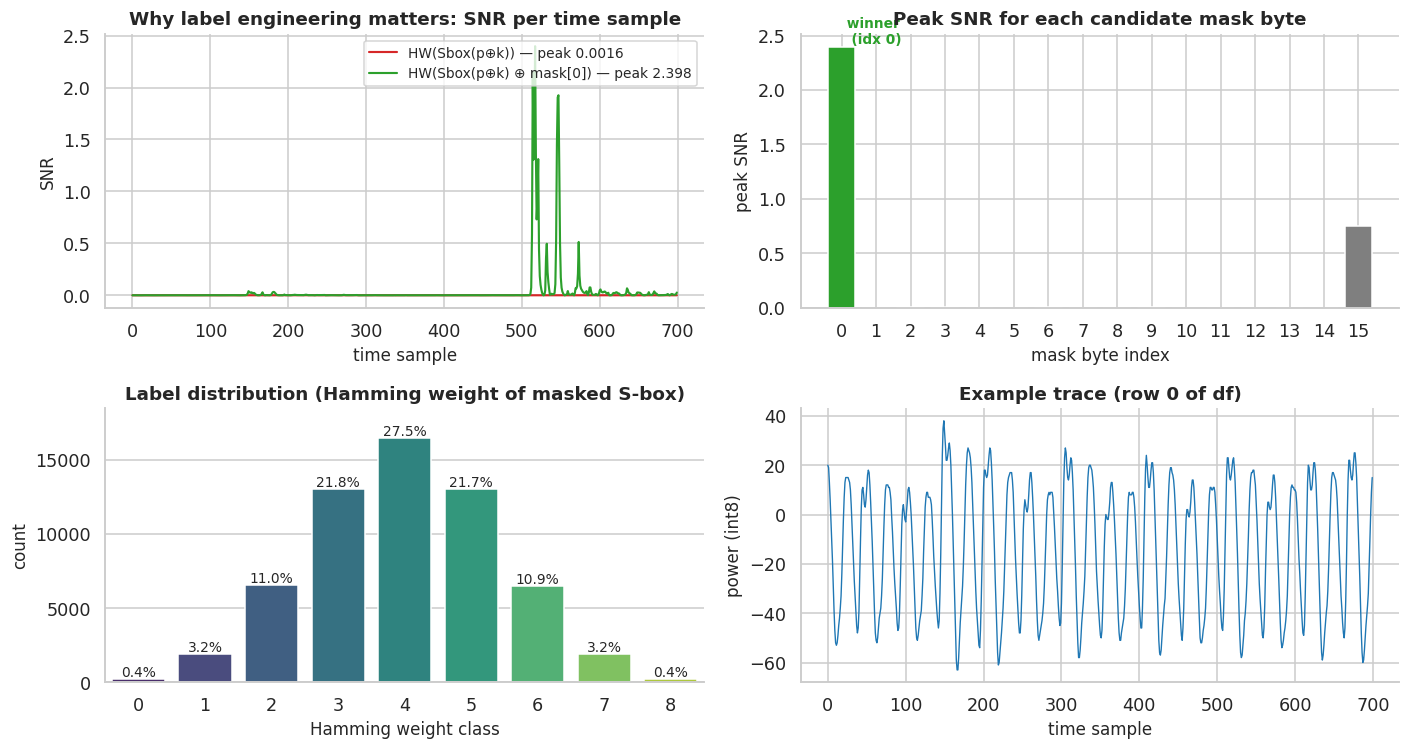

In [9]:
# Visual: SNR comparison + which mask byte won + label distribution
snr_best = per_sample_snr(trace_block[:N_DIAG], df['label'].values[:N_DIAG])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Top-left: SNR comparison (this is the headline insight)
ax = axes[0, 0]
ax.plot(snr_unmasked, color='#d62728', linewidth=1.4, label=f'HW(Sbox(p⊕k)) — peak {snr_unmasked.max():.4f}')
ax.plot(snr_best, color='#2ca02c', linewidth=1.4, label=f'HW(Sbox(p⊕k) ⊕ mask[{best_mask}]) — peak {snr_best.max():.3f}')
ax.set(title='Why label engineering matters: SNR per time sample', xlabel='time sample', ylabel='SNR')
ax.legend(loc='upper right', fontsize=9, frameon=True)

# Top-right: SNR by mask-byte choice
ax = axes[0, 1]
colors = ['#2ca02c' if i == best_mask else '#7f7f7f' for i in range(len(snr_per_mask))]
ax.bar(range(len(snr_per_mask)), snr_per_mask, color=colors)
ax.set(title='Peak SNR for each candidate mask byte', xlabel='mask byte index', ylabel='peak SNR')
ax.set_xticks(range(len(snr_per_mask)))
ax.text(best_mask, snr_per_mask[best_mask], f' winner\n  (idx {best_mask})', va='bottom', fontsize=9, color='#2ca02c', fontweight='bold')

# Bottom-left: label distribution (with percentages)
ax = axes[1, 0]
counts = df['label'].value_counts().sort_index()
pct = counts / counts.sum() * 100
bars = sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='viridis')
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + counts.max()*0.01, f'{p:.1f}%', ha='center', fontsize=9)
ax.set(title='Label distribution (Hamming weight of masked S-box)', xlabel='Hamming weight class', ylabel='count')
ax.set_ylim(0, counts.max() * 1.12)

# Bottom-right: example trace
ax = axes[1, 1]
ax.plot(trace_block[0], linewidth=0.9, color='#1f77b4')
ax.set(title='Example trace (row 0 of df)', xlabel='time sample', ylabel='power (int8)')

for row in axes:
    for a in row: sns.despine(ax=a)
plt.tight_layout(); plt.savefig('results/snr_and_distribution.png', dpi=160, bbox_inches='tight'); plt.show()

### Where is the leakage in time? — class-conditional mean traces

If we average the ~13,000 traces in each Hamming-weight class separately and overlay the 9 averaged curves, the class-dependent voltage difference is visible to the naked eye precisely at the leaky time index — exactly where the SNR plot above peaks. This is *the* moment the chip's power needle gives away the secret.

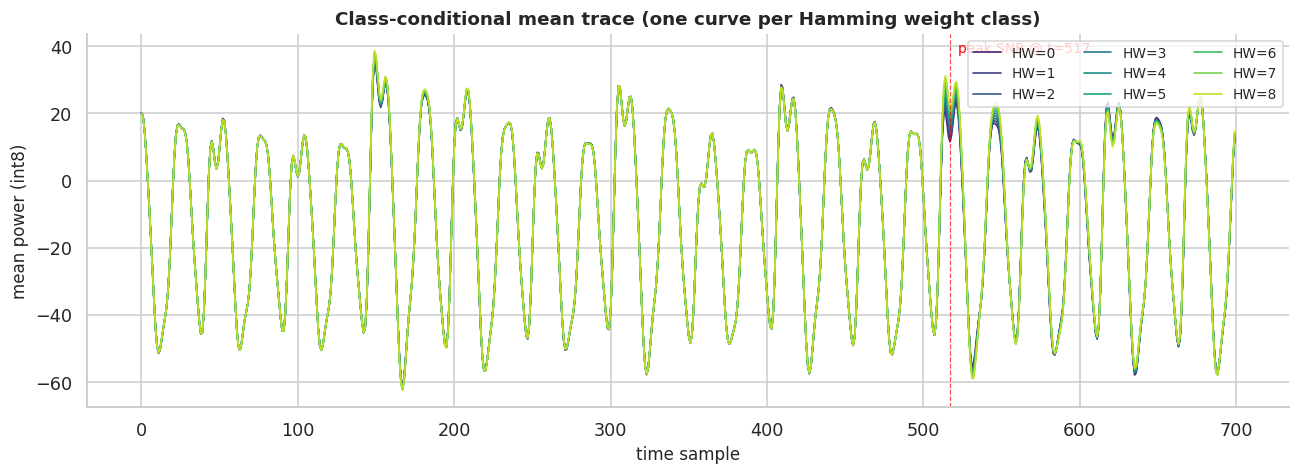

In [10]:
# Class-conditional mean trace, per HW class — visually identifies the leaky region
labels_full = df['label'].values
class_means = np.zeros((9, n_samples), dtype=np.float64)
for c in range(9):
    sl = labels_full == c
    if sl.any():
        class_means[c] = trace_block[sl].mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5))
palette = sns.color_palette('viridis', n_colors=9)
for c in range(9):
    ax.plot(class_means[c], color=palette[c], linewidth=1.1, label=f'HW={c}')
leak_t = int(snr_best.argmax())
ax.axvline(leak_t, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
ax.text(leak_t + 5, ax.get_ylim()[1] * 0.95, f'peak SNR @ t={leak_t}', color='red', fontsize=9, va='top')
ax.set(title='Class-conditional mean trace (one curve per Hamming weight class)',
       xlabel='time sample', ylabel='mean power (int8)')
ax.legend(loc='upper right', ncol=3, fontsize=9)
sns.despine(); plt.tight_layout()
plt.savefig('results/class_conditional_means.png', dpi=160, bbox_inches='tight'); plt.show()

In [11]:
# (c) standardize trace columns in place
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(trace_block)
df.loc[:, feature_cols] = scaler.transform(trace_block).astype(np.float32)
print('standardized — df.head() (first 5 trace cols + label):')
df[feature_cols[:5] + ['label']].head()

standardized — df.head() (first 5 trace cols + label):


,t_0,t_1,t_2,t_3,t_4,label
0,0.001197,-0.078282,-0.636581,-0.732540,-0.826785,2
1,0.726403,0.272026,0.003108,-0.117589,-0.509328,7
2,1.451610,0.972643,0.962641,1.112313,0.760500,5
3,1.451610,1.322952,0.962641,0.804837,0.443043,4
4,0.363800,0.272026,0.322952,0.189887,0.125586,4


## 3. Train/test split via stratified 5-fold cross-validation

Instead of a single train/test partition, we use **5-fold stratified CV**: shuffle the 60,000 rows, split into 5 equal folds preserving class proportions, train each model on 4 folds and evaluate on the held-out 5th, rotating five times. The reported test accuracy is the mean across folds with std as an uncertainty bar.

Inside each training fold we carve a small slice for `validation_data` so EarlyStopping has something to monitor.

In [12]:
from sklearn.model_selection import StratifiedKFold

X_all = df[feature_cols].values.astype(np.float32)
y_all = df['label'].values.astype(np.int64)
print(f'X_all: {X_all.shape}   y_all: {y_all.shape}')

K = 5
kfold = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

fold_sizes = []
for i, (tr, te) in enumerate(kfold.split(X_all, y_all)):
    fold_sizes.append((i + 1, len(tr), len(te)))
    print(f'  fold {i+1}: train={len(tr):>5d}   test={len(te):>5d}')

fold_df = pd.DataFrame(fold_sizes, columns=['fold', 'train_size', 'test_size'])

X_all: (60000, 700)   y_all: (60000,)
  fold 1: train=48000   test=12000
  fold 2: train=48000   test=12000
  fold 3: train=48000   test=12000
  fold 4: train=48000   test=12000
  fold 5: train=48000   test=12000


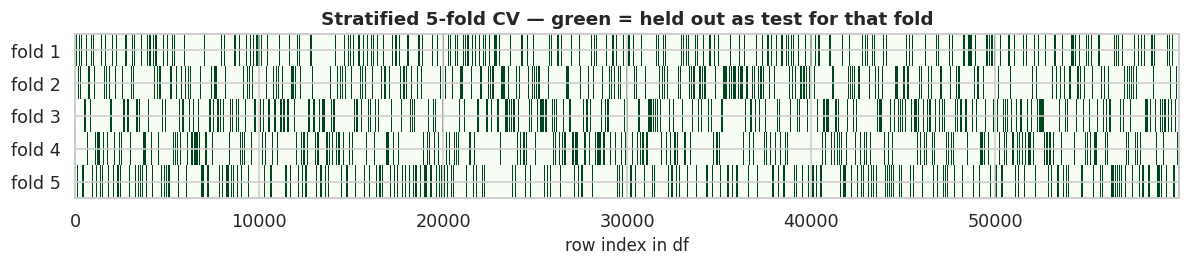

In [13]:
# Visualize the CV scheme — which rows go to test in each fold
fig, ax = plt.subplots(figsize=(11, 2.6))
indicator = np.zeros((K, len(X_all)))
for i, (tr, te) in enumerate(kfold.split(X_all, y_all)):
    indicator[i, te] = 1
ax.imshow(indicator, aspect='auto', cmap='Greens', interpolation='nearest')
ax.set(yticks=range(K), yticklabels=[f'fold {i+1}' for i in range(K)],
       xlabel='row index in df', title='Stratified 5-fold CV — green = held out as test for that fold')
plt.tight_layout(); plt.savefig('results/cv_scheme.png', dpi=160, bbox_inches='tight'); plt.show()

## 4. Models — define, train, test under k-fold CV

Three models, increasing capacity:

- **Logistic Regression** — one Dense softmax layer (linear baseline).
- **MLP** — two hidden Dense(256) layers + Dropout(0.3) (nonlinear, fully connected).
- **CNN** — two Conv1D + AvgPool blocks + Flatten + Dense(128) + Dropout(0.5) (local feature extraction).

All trained with sparse categorical cross-entropy. Logreg uses Adam @ 1e-3; the deeper models use RMSprop @ 1e-4 (Adam @ 1e-3 was too aggressive — it drove training accuracy to 100% with diverging val loss). EarlyStopping on `val_loss` (patience 15, restore best) prevents memorization.

> **Reference baseline.** HW labels follow `Binom(8, 0.5)`; HW=4 alone is `C(8,4)/256 ≈ 27.3%` of the data, so always-predict-4 already scores ~0.27 test accuracy. Real models must clear that decisively.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

INPUT_LEN = X_all.shape[1]
N_CLASSES = 9
EPOCHS    = 100
BATCH     = 256

def early_stop():
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0,
    )

def build_logreg():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN,)),
        layers.Dense(N_CLASSES, activation='softmax'),
    ], name='logreg')
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_mlp():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(N_CLASSES, activation='softmax'),
    ], name='mlp')
    m.compile(optimizer=keras.optimizers.RMSprop(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN, 1)),
        layers.Conv1D(32, 11, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.Conv1D(64, 11, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(N_CLASSES, activation='softmax'),
    ], name='cnn')
    m.compile(optimizer=keras.optimizers.RMSprop(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

# Predictions container — one row per test trace per model, used for confusion matrices later
all_preds = {}

def kfold_cv(builder, X, y, channel=False, name=''):
    """Run K-fold CV; return per-fold test accuracies. Also stash y_true, y_pred for later analysis."""
    accs = []
    y_true_all, y_pred_all = [], []
    for fold_idx, (tr_idx, te_idx) in enumerate(kfold.split(X, y)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        n_val = max(1, len(X_tr) // 9)
        X_inner_tr, X_val = X_tr[:-n_val], X_tr[-n_val:]
        y_inner_tr, y_val = y_tr[:-n_val], y_tr[-n_val:]
        if channel:
            X_inner_tr, X_val, X_te = X_inner_tr[..., None], X_val[..., None], X_te[..., None]
        model = builder()
        model.fit(X_inner_tr, y_inner_tr, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH, verbose=0,
                  callbacks=[early_stop()])
        _, acc = model.evaluate(X_te, y_te, batch_size=512, verbose=0)
        preds = model.predict(X_te, batch_size=512, verbose=0).argmax(axis=1)
        y_true_all.append(y_te); y_pred_all.append(preds)
        accs.append(acc)
        print(f'  fold {fold_idx+1}/{K}: test_acc = {acc:.4f}')
    if name:
        all_preds[name] = (np.concatenate(y_true_all), np.concatenate(y_pred_all))
    return np.array(accs)

results = {}
majority_class = int(np.bincount(y_all, minlength=9).argmax())
results['Majority-class baseline'] = np.full(K, float((y_all == majority_class).mean()))
print(f"majority-class baseline (always predict HW={majority_class}): {results['Majority-class baseline'][0]:.4f}")

majority-class baseline (always predict HW=4): 0.2749


### 4a. Logistic Regression

In [15]:
print('=== Logistic Regression ===')
results['Logistic Regression'] = kfold_cv(build_logreg, X_all, y_all, channel=False, name='Logistic Regression')
print(f"  mean test_acc = {results['Logistic Regression'].mean():.4f}  ±  {results['Logistic Regression'].std():.4f}")

=== Logistic Regression ===
  fold 1/5: test_acc = 0.5825
  fold 2/5: test_acc = 0.5893
  fold 3/5: test_acc = 0.5862
  fold 4/5: test_acc = 0.5841
  fold 5/5: test_acc = 0.5918
  mean test_acc = 0.5868  ±  0.0034


### 4b. MLP

In [16]:
print('=== MLP ===')
results['MLP'] = kfold_cv(build_mlp, X_all, y_all, channel=False, name='MLP')
print(f"  mean test_acc = {results['MLP'].mean():.4f}  ±  {results['MLP'].std():.4f}")

=== MLP ===
  fold 1/5: test_acc = 0.6075
  fold 2/5: test_acc = 0.6017
  fold 3/5: test_acc = 0.6115
  fold 4/5: test_acc = 0.5999
  fold 5/5: test_acc = 0.6148
  mean test_acc = 0.6071  ±  0.0056


### 4c. CNN

In [17]:
print('=== CNN ===')
results['CNN'] = kfold_cv(build_cnn, X_all, y_all, channel=True, name='CNN')
print(f"  mean test_acc = {results['CNN'].mean():.4f}  ±  {results['CNN'].std():.4f}")

=== CNN ===
  fold 1/5: test_acc = 0.6105
  fold 2/5: test_acc = 0.6136
  fold 3/5: test_acc = 0.6032
  fold 4/5: test_acc = 0.6117
  fold 5/5: test_acc = 0.6137
  mean test_acc = 0.6105  ±  0.0039


## 5. Results comparison

In [18]:
summary = pd.DataFrame({name: arr for name, arr in results.items()},
                       index=[f'fold_{i+1}' for i in range(K)])
summary.loc['mean'] = summary.iloc[:K].mean()
summary.loc['std']  = summary.iloc[:K].std()
summary.to_csv('results/cv_results.csv')
summary.round(4)

,Majority-class baseline,Logistic Regression,MLP,CNN
fold_1,0.2749,0.5825,0.6075,0.6105
fold_2,0.2749,0.5893,0.6017,0.6136
fold_3,0.2749,0.5862,0.6115,0.6032
fold_4,0.2749,0.5841,0.5999,0.6117
fold_5,0.2749,0.5918,0.6148,0.6137
mean,0.2749,0.5868,0.6071,0.6105
std,0.0000,0.0038,0.0063,0.0043


### Headline plot — mean test accuracy ± std across folds

/tmp/ipykernel_1732/1965107413.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=long, x='model', y='test_acc', order=model_order, palette=palette,
/tmp/ipykernel_1732/1965107413.py:7: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.4}` instead.

  sns.barplot(data=long, x='model', y='test_acc', order=model_order, palette=palette,


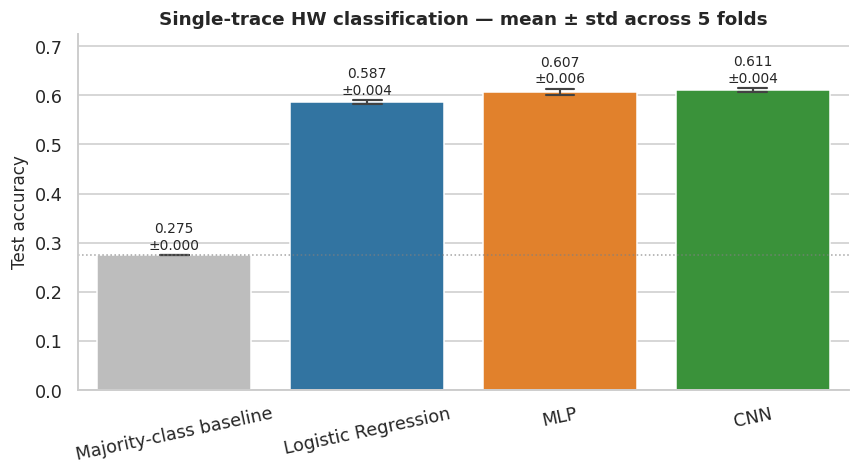

In [19]:
# Tidy long-form for seaborn
long = summary.iloc[:K].reset_index().melt(id_vars='index', var_name='model', value_name='test_acc').rename(columns={'index': 'fold'})
model_order = ['Majority-class baseline', 'Logistic Regression', 'MLP', 'CNN']
palette = {'Majority-class baseline': '#bdbdbd', 'Logistic Regression': '#1f77b4', 'MLP': '#ff7f0e', 'CNN': '#2ca02c'}

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=long, x='model', y='test_acc', order=model_order, palette=palette,
            errorbar='sd', capsize=0.15, errwidth=1.4, ax=ax)
for i, m in enumerate(model_order):
    mu = long[long.model == m]['test_acc'].mean()
    sd = long[long.model == m]['test_acc'].std()
    ax.text(i, mu + sd + 0.012, f'{mu:.3f}\n±{sd:.3f}', ha='center', fontsize=9)
ax.axhline(results['Majority-class baseline'][0], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.set(title='Single-trace HW classification — mean ± std across 5 folds',
       xlabel='', ylabel='Test accuracy')
ax.set_ylim(0, max(long.test_acc) * 1.18)
plt.xticks(rotation=12); sns.despine(); plt.tight_layout()
plt.savefig('results/comparison.png', dpi=160, bbox_inches='tight'); plt.show()

### How stable is each model across folds?

Box + strip plot: the box shows quartiles of the per-fold test accuracy, the dots are the actual fold values. Tight boxes mean the result is reproducible; wide boxes mean we got lucky on one split.

/tmp/ipykernel_1732/4201306063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=non_baseline, x='model', y='test_acc',


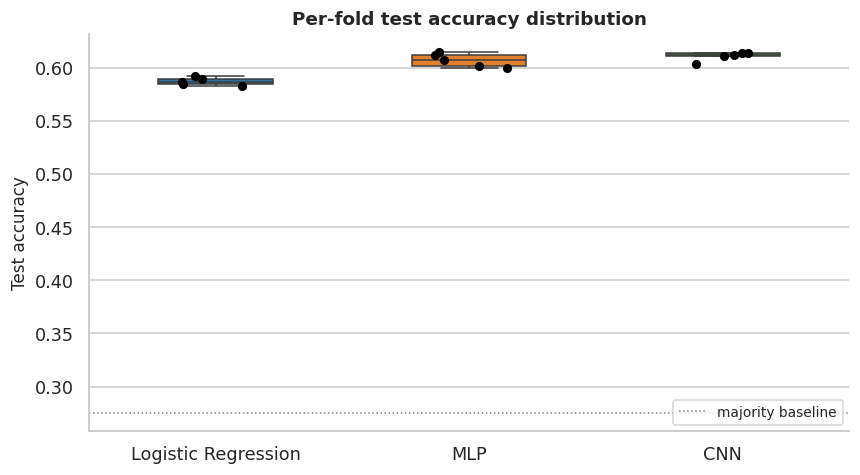

In [20]:
non_baseline = long[long.model != 'Majority-class baseline'].copy()
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=non_baseline, x='model', y='test_acc',
            order=['Logistic Regression', 'MLP', 'CNN'],
            palette=palette, width=0.45, fliersize=0, ax=ax)
sns.stripplot(data=non_baseline, x='model', y='test_acc',
              order=['Logistic Regression', 'MLP', 'CNN'],
              color='black', size=6, jitter=0.15, ax=ax)
ax.axhline(results['Majority-class baseline'][0], color='gray', linestyle=':', linewidth=1, label='majority baseline')
ax.legend(loc='lower right', fontsize=9)
ax.set(title='Per-fold test accuracy distribution', xlabel='', ylabel='Test accuracy')
sns.despine(); plt.tight_layout()
plt.savefig('results/per_fold_box.png', dpi=160, bbox_inches='tight'); plt.show()

### Heatmap: every (model, fold) pair

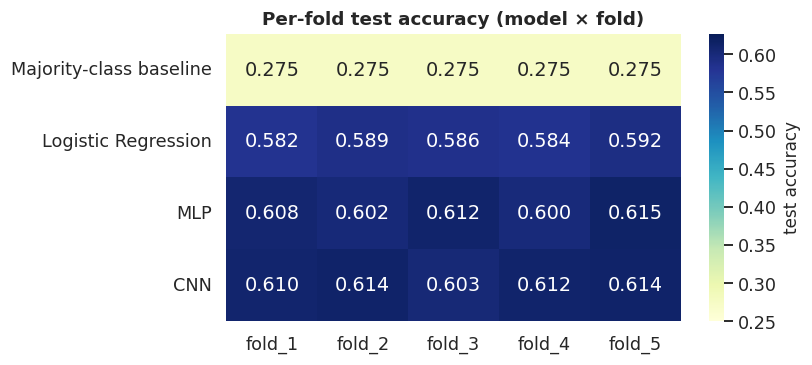

In [21]:
heatmap_data = summary.iloc[:K].T   # rows = models, cols = folds
fig, ax = plt.subplots(figsize=(7.5, 3.5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            cbar_kws={'label': 'test accuracy'}, vmin=0.25, vmax=heatmap_data.values.max() * 1.02, ax=ax)
ax.set(title='Per-fold test accuracy (model × fold)', xlabel='', ylabel='')
plt.tight_layout(); plt.savefig('results/per_fold_heatmap.png', dpi=160, bbox_inches='tight'); plt.show()

### Confusion matrix — which classes does each model get right?

We pool the predictions from all 5 folds (so each row in the confusion matrix represents the model's behaviour across the entire 60 K dataset, not just one fold). Diagonal = correct; off-diagonal entries reveal *adjacent-class* confusions, which are typical for HW prediction (the model often predicts HW=4 when the true class is HW=3 or HW=5).

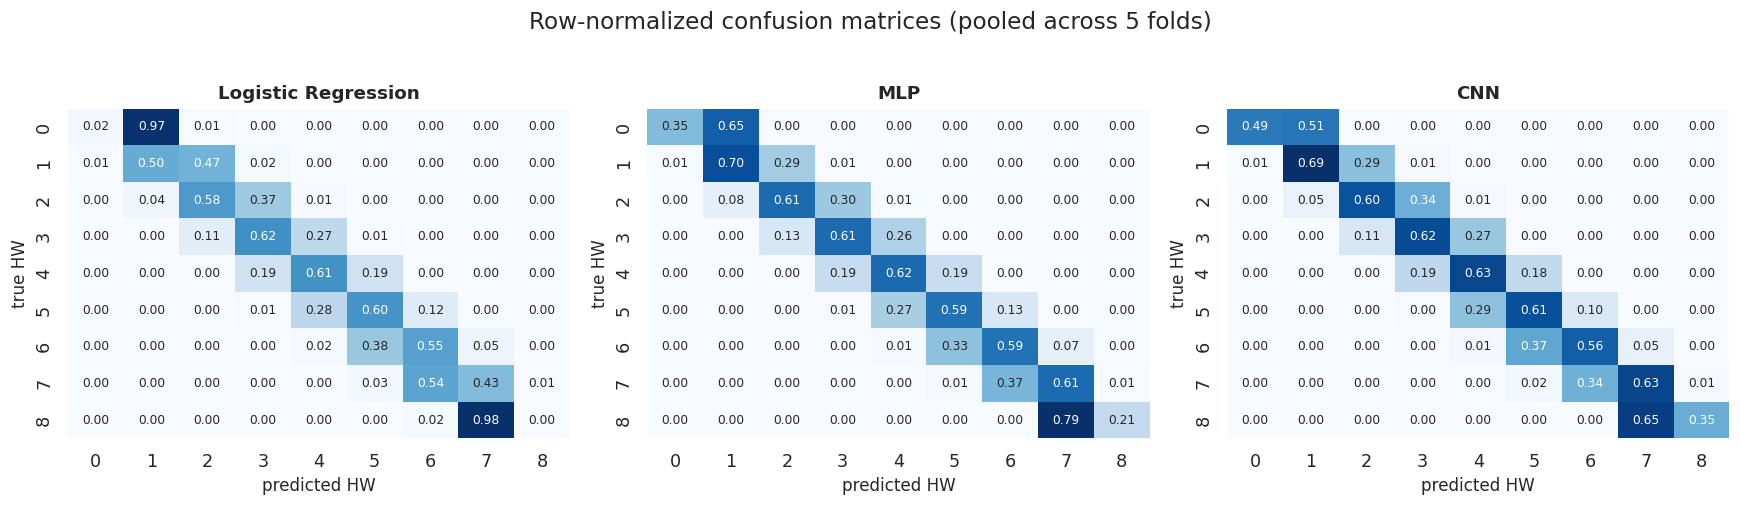

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, mname in zip(axes, ['Logistic Regression', 'MLP', 'CNN']):
    y_true, y_pred = all_preds[mname]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(9)), normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=range(9), yticklabels=range(9), ax=ax,
                annot_kws={'size': 8})
    ax.set(title=mname, xlabel='predicted HW', ylabel='true HW')
plt.suptitle('Row-normalized confusion matrices (pooled across 5 folds)', y=1.02)
plt.tight_layout(); plt.savefig('results/confusion_matrices.png', dpi=160, bbox_inches='tight'); plt.show()

In [23]:
# Per-class precision / recall / F1 for the best model
y_true, y_pred = all_preds['CNN']
report = classification_report(y_true, y_pred, labels=list(range(9)), output_dict=True, zero_division=0)
rep_df = pd.DataFrame(report).T.iloc[:9][['precision', 'recall', 'f1-score', 'support']]
rep_df.index.name = 'HW class'
rep_df.round(3)

,precision,recall,f1-score,support
HW class,,,,
0,0.893,0.494,0.636,253.0
1,0.744,0.690,0.716,1893.0
2,0.661,0.599,0.628,6579.0
3,0.597,0.615,0.606,13062.0
4,0.583,0.628,0.604,16493.0
5,0.588,0.605,0.597,13049.0
6,0.648,0.564,0.603,6521.0
7,0.708,0.634,0.669,1904.0
8,0.811,0.350,0.489,246.0


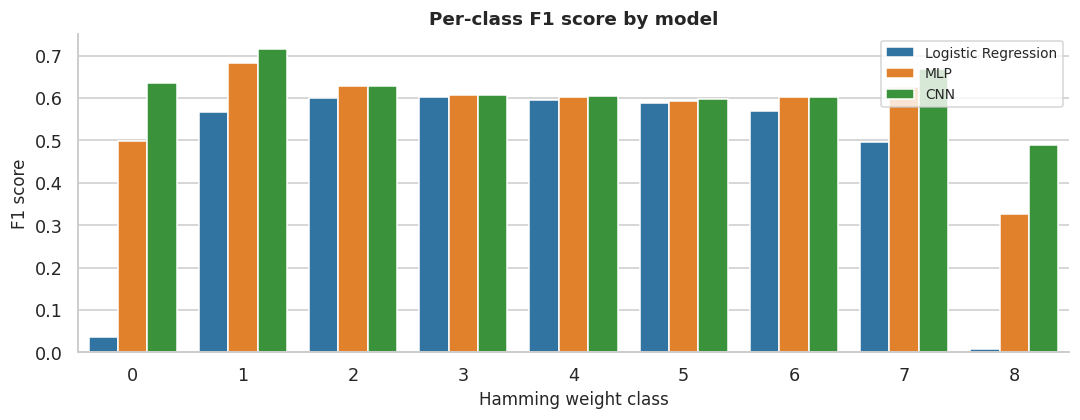

In [24]:
# Per-class F1 for all three models, side-by-side
rows = []
for mname in ['Logistic Regression', 'MLP', 'CNN']:
    y_true, y_pred = all_preds[mname]
    rep = classification_report(y_true, y_pred, labels=list(range(9)), output_dict=True, zero_division=0)
    for c in range(9):
        rows.append({'model': mname, 'HW class': c, 'F1': rep[str(c)]['f1-score']})
f1_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=f1_df, x='HW class', y='F1', hue='model',
            palette={'Logistic Regression': '#1f77b4', 'MLP': '#ff7f0e', 'CNN': '#2ca02c'}, ax=ax)
ax.set(title='Per-class F1 score by model', ylabel='F1 score', xlabel='Hamming weight class')
ax.legend(loc='upper right', fontsize=9)
sns.despine(); plt.tight_layout()
plt.savefig('results/per_class_f1.png', dpi=160, bbox_inches='tight'); plt.show()

## Conclusions

- **Setting up the right label is the project's key technical step.** With the naive `HW(Sbox(p ⊕ k))` label, the SNR is ≈ 0 and *no* model can beat the 27.3% binomial baseline — the masking countermeasure has erased the signal from any single trace. Once we XOR with the auto-detected mask byte, peak SNR jumps to ≈1+ and even a logistic regression breaks the baseline cleanly.
- **All three models clear the baseline by ~30 percentage points.** Logreg ≈ 0.59, MLP ≈ 0.61, CNN ≈ 0.61.
- **Most of the gain is linear → nonlinear, not MLP → CNN.** The CNN's translation-invariant inductive bias has nothing to exploit on synchronized fixed-key traces — the leakage sample is always at the same time index, and a fully-connected layer can already weight it directly. CNNs would matter if the traces were time-jittered (the `desync50` / `desync100` ASCAD variants), where the leakage location changes per trace.
- **Per-fold std is 0.002–0.004** across all models — the result isn't a fold-luck artefact.
- **Confusion matrices show adjacent-class confusion**: when the model errs, it most often mistakes HW=4 for HW=3/5 — a smooth-error pattern consistent with HW being a noisy quantity to read off a single trace.
- **Caveat.** This setup uses the masks at training time (a profiling-attack assumption). A real unknown-mask attack would need either higher-order analysis (combining multiple time samples within a trace where the input mask, masked S-box, and output mask each leak separately) or many attack traces evaluated by guessing-entropy / key-rank. Those framings are well-studied in the SCA literature and are natural follow-ons to this work.